# Utils

In [1]:
def euclidean_distance(x, y):
    return np.sum((x - y) ** 2)

# K Nearest Neighbours

In [2]:
import numpy as np
# from collections import Counter

class KNN:
    def __init__(self, k=3):
        self.k = k

    def fit(self, X, y):
        self.X_train = X
        self.y_train = y

    def predict(self, X):
        predictions = [self._predict(x) for x in X]
        return predictions

    def _predict(self, x):
        distances = [euclidean_distance(x, x_train) for x_train in self.X_train]
        
        k_nearest_indeces = np.argsort(distances)[:self.k]
        k_nearest_labels = [self.y_train[i] for i in k_nearest_indeces]

        # labels_counts = Counter(k_nearest_labels)
        labels_counts = {label: k_nearest_labels.count(label) for label in set(k_nearest_labels)}
        most_common_label = max(labels_counts, key=labels_counts.get)

        return most_common_label

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

Text(0.5, 0, 'Our prediction classfication')

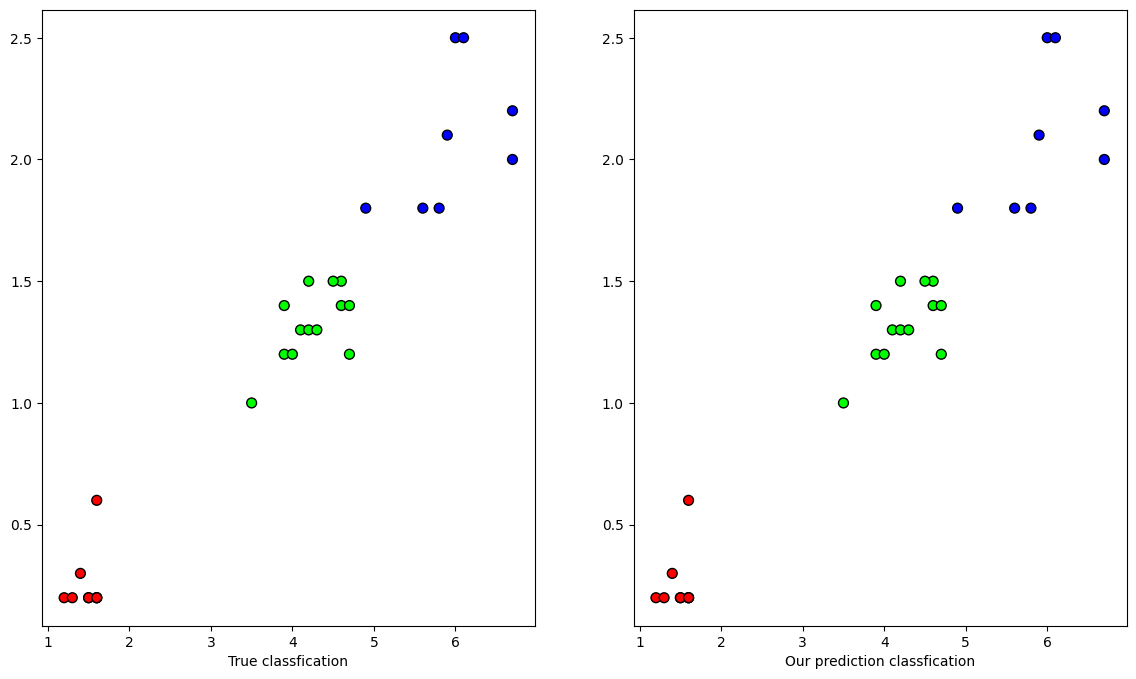

In [12]:
import numpy as np
from sklearn import datasets
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
cmap = ListedColormap(['#FF0000', '#00FF00', '#0000FF'])

iris = datasets.load_iris()
X, y = iris.data, iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1234
)

print(iris.DESCR)

fig, axs = plt.subplots(1, 2, figsize=(14,8))

axs[0].scatter(X_test[:,2], X_test[:,3], c=y_test, cmap=cmap, edgecolor='k', s=50)
axs[0].set_xlabel('True classfication')

clf = KNN()
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

axs[1].scatter(X_test[:,2], X_test[:,3], c=y_pred, cmap=cmap, edgecolor='k', s=50)
axs[1].set_xlabel('Our prediction classfication')

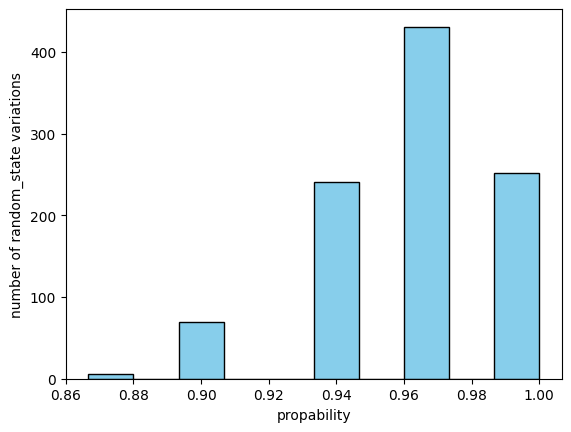

In [13]:
accs = []
for rs in range(0, 10000, 10):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=rs
    )
    knn = KNN(k=3)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    acc = np.mean(y_pred == y_test)
    accs.append(acc)

plt.hist(accs, color='skyblue', edgecolor='k')
plt.ylabel('number of random_state variations')
plt.xlabel('propability')
plt.show()

# Linear Regression

In [5]:
import numpy as np

class LinearRegression:
    def __init__(self, lr=0.001, n_iters=1000):
        self.lr = lr
        self.n_iters = n_iters
        self.weights = None
        self.bias = None

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0

        for _ in range(self.n_iters):
            y_pred = X @ self.weights + self.bias
            
            dw = X.T @ (y_pred - y) / n_samples
            db = np.sum(y_pred - y) / n_samples
            
            self.weights = self.weights - self.lr * dw
            self.bias = self.bias - self.lr * db
        
    def predict(self, X):
        y_pred = X @ self.weights + self.bias
        return y_pred

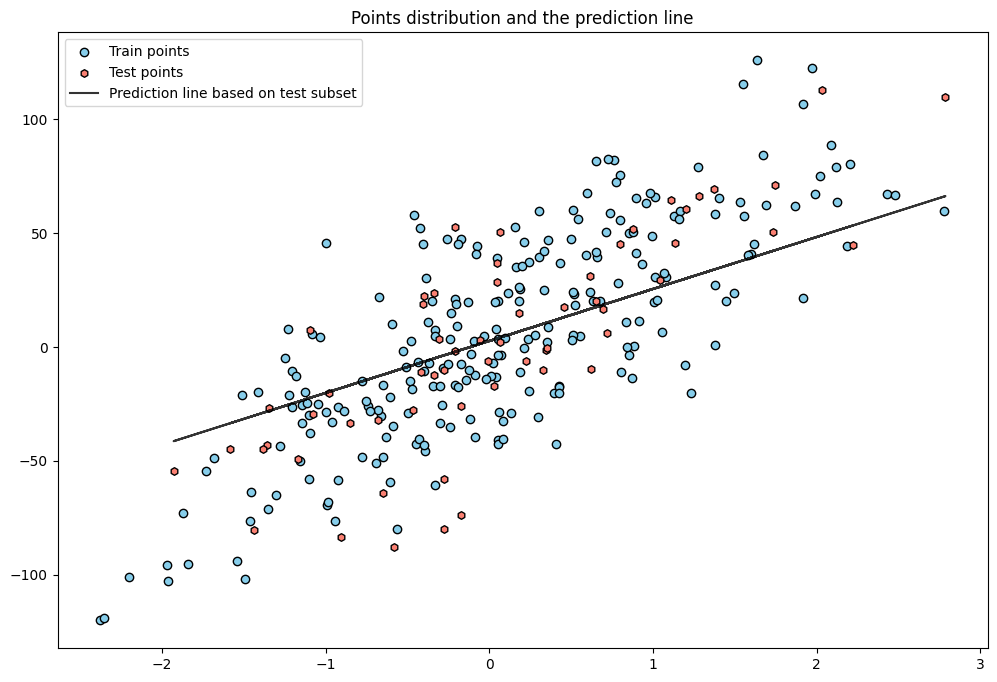

In [6]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn import datasets
import matplotlib.pyplot as plt

X, y = datasets.make_regression(
    n_samples=300, n_features=1, noise=30, random_state=4
)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1234
)

regression = LinearRegression()
regression.fit(X_train, y_train)
y_pred = regression.predict(X_test)

fig, ax = plt.subplots(figsize=(12,8))
plt.scatter(X_train[:,0], y_train, color='skyblue', marker='o', edgecolors='k', label='Train points')
plt.scatter(X_test[:,0], y_test, color='salmon', marker='h', edgecolors='k', s=30, label='Test points')
plt.plot(X_test, y_pred, color='k', alpha=0.8, label='Prediction line based on test subset')
plt.title('Points distribution and the prediction line')
plt.legend()
plt.show()

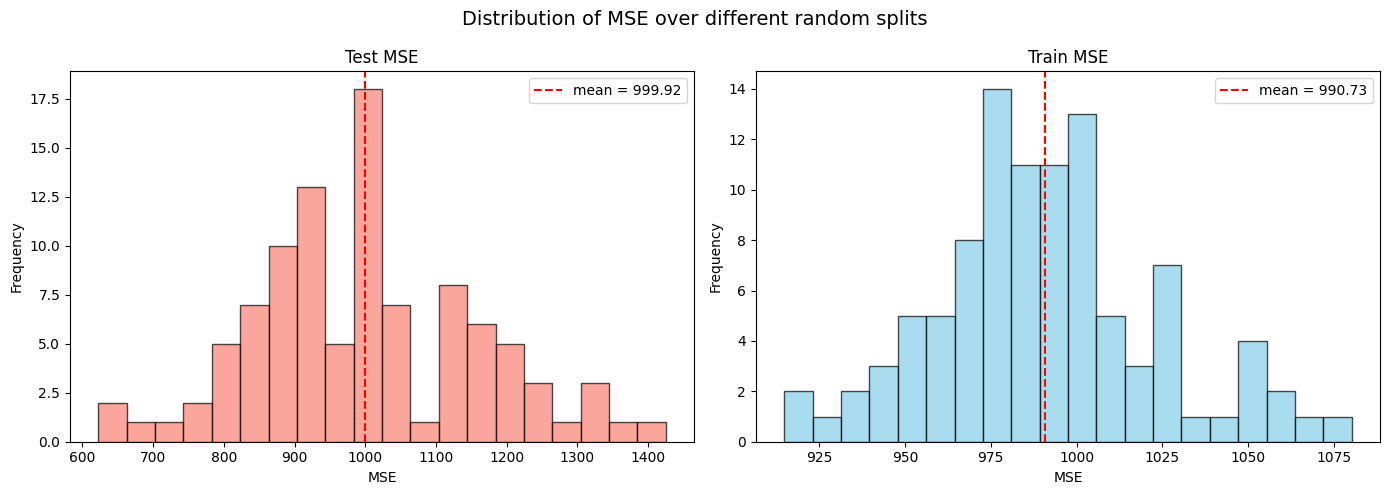

Средний MSE на тесте: 999.92 ± 160.99
Средний MSE на обучении: 990.73 ± 32.14
Невязка (Test - Train): 9.19


In [7]:
mses_test = []
mses_train = []

random_states = range(0, 10000, 100)

for rs in random_states:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=rs
    )
    
    model = LinearRegression()
    model.fit(X_train, y_train)
    
    y_pred_test = model.predict(X_test)
    mse_test = np.mean((y_test - y_pred_test) ** 2)
    mses_test.append(mse_test)
    
    y_pred_train = model.predict(X_train)
    mse_train = np.mean((y_train - y_pred_train) ** 2)
    mses_train.append(mse_train)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.hist(mses_test, bins=20, edgecolor='k', alpha=0.7, color='salmon')
ax1.axvline(np.mean(mses_test), color='red', linestyle='--', label=f'mean = {np.mean(mses_test):.2f}')
ax1.set_xlabel('MSE')
ax1.set_ylabel('Frequency')
ax1.set_title('Test MSE')
ax1.legend()

ax2.hist(mses_train, bins=20, edgecolor='k', alpha=0.7, color='skyblue')
ax2.axvline(np.mean(mses_train), color='red', linestyle='--', label=f'mean = {np.mean(mses_train):.2f}')
ax2.set_xlabel('MSE')
ax2.set_ylabel('Frequency')
ax2.set_title('Train MSE')
ax2.legend()

fig.suptitle('Distribution of MSE over different random splits', fontsize=14)
plt.tight_layout()
plt.show()

print(f"Средний MSE на тесте: {np.mean(mses_test):.2f} ± {np.std(mses_test):.2f}")
print(f"Средний MSE на обучении: {np.mean(mses_train):.2f} ± {np.std(mses_train):.2f}")
print(f"Невязка (Test - Train): {np.mean(mses_test) - np.mean(mses_train):.2f}")

# Logistic Regression

In [57]:
import numpy as np

def sigmoid(z):
    z = np.clip(z, -500, 500)
    return 1 / (1 + np.exp(-z))

class LogisticRegression():

    def __init__(self, lr=0.001, n_iters=1000):
        self.lr = lr
        self.n_iters = n_iters
        self.weights = None
        self.bias = None

    def fit(self, X, y):
        n_samples, n_features = X.shape
        
        self.weights = np.zeros(n_features)
        self.bias = 0

        for _ in range(self.n_iters):
            linear_predictions = X @ self.weights + self.bias
            y_pred = sigmoid(linear_predictions)

            dw = X.T @ (y_pred - y) / n_samples
            db = np.sum(y_pred - y) / n_samples

            self.weights = self.weights - self.lr * dw
            self.bias = self.bias - self.lr * db

    def predict(self, X):
        linear_predictions = X @ self.weights + self.bias
        y_pred = sigmoid(linear_predictions)
        labels = [0 if y < 0.5 else 1 for y in y_pred]
        return labels

.. _breast_cancer_dataset:

Breast cancer Wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed for each image,
    resulting in 30 features.  For instance, field 0 is Mean Radius, field
    10 is Radius SE, field 20 is Worst Radius.

    - 

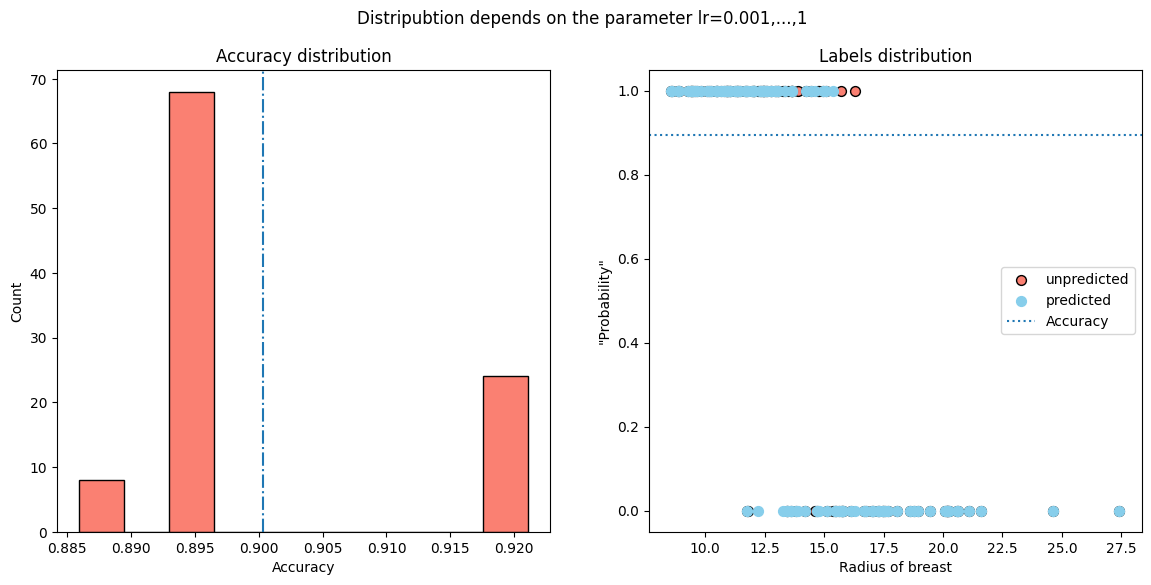

In [108]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn import datasets
import matplotlib.pyplot as plt

bc = datasets.load_breast_cancer()
X, y = bc.data, bc.target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1234
)

print(bc.DESCR)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,6))

accs = []
for d in range(1, 1000, 10):
    clf = LogisticRegression(lr = 1 / d)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    
    acc = np.sum(y_pred == y_test) / len(y_test)
    accs.append(acc)

mean = sum(accs) / len(accs)
ax1.hist(accs, bins=10, color='salmon', edgecolor='k')
ax1.axvline(mean, linestyle='-.', label='Mean accuracy')

ax1.set_title('Accuracy distribution')
ax1.set_ylabel('Count')
ax1.set_xlabel('Accuracy')

ax2.set_title('Labels distribution')
ax2.scatter(X_test[:, 0], y_test, color='salmon', edgecolor='k', s=50, label='unpredicted')
ax2.scatter(X_test[:, 0], y_pred, color='skyblue', s=50, label='predicted')
ax2.axhline(acc, linestyle=':', label='Accuracy')
ax2.set_ylabel('"Probability"')
ax2.set_xlabel('Radius of breast')

fig.suptitle('Distripubtion depends on the parameter lr=0.001,...,1')
plt.legend()
plt.show()

# Decision Trees

In [104]:
import numpy as np
from collections import Counter


class Node:
    def __init__(self, feature=None, threshold=None, left=None, right=None, *, value=None):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value

    def is_leaf_node(self):
        return self.value is not None

class DecisionTree:
    def  __init__(self, min_samples_split=2, max_depth=100, n_features=None):
        self.min_samples_split = min_samples_split
        self.max_depth = max_depth
        self.n_features = n_features
        self.root = None

    def fit(self, X, y):
        self.n_features = X.shape[1] if not self.n_features else min(X.shape[1], self.n_features)
        self.root = self._grow_tree(X, y)

    def _grow_tree(self, X, y, depth=0):
        n_samples, n_features = X.shape
        n_labels = len(np.unique(y))

        # check the stopping criteria
        if (depth >= self.max_depth 
            or n_labels == 1 
            or n_samples < self.min_samples_split):
            
            leaf_value = self._most_common_label(y)
            return Node(value=leaf_value)
        
        feature_idxs = np.random.choice(n_features, self.n_features, replace=False)
        
        # find the best split
        best_feature, best_threshold = self._best_split(X, y, feature_idxs)
        
        # create child nodes
        left_idxs, right_idxs = self._split(X[:, best_feature], best_threshold)
        left = self._grow_tree(X[left_idxs, :], y[left_idxs], depth + 1)
        right = self._grow_tree(X[right_idxs, :], y[right_idxs], depth + 1)
        return Node(best_feature, best_threshold, left, right)
            
    def _best_split(self, X, y, feature_idxs):
        best_gain = -1
        split_idx, split_threshold = None, None

        for feature_idx in feature_idxs:
            X_column = X[:, feature_idx]
            thresholds = np.unique(X_column)

            for threshold in thresholds:
                # calculate the information gain
                gain = self._information_gain(y, X_column, threshold)

                if gain > best_gain:
                    best_gain = gain
                    split_idx = feature_idx
                    split_threshold = threshold

        return split_idx, split_threshold

    def _information_gain(self, y, X_column, threshold):
        # parent entropy
        parent_entropy = self._entropy(y)

        # create children
        left_idxs, right_idxs = self._split(X_column, threshold)

        if len(left_idxs) == 0 or len(right_idxs) == 0:
            return 0

        # calculate the avg. weighted entropy of children 
        n = len(y)
        n_l, n_r = len(left_idxs), len(right_idxs)
        e_l, e_r = self._entropy(y[left_idxs]), self._entropy(y[right_idxs])
        child_entropy = (n_l/n) * e_l + (n_r/n) * e_r

        # calculate the IG
        information_gain = parent_entropy - child_entropy
        return information_gain

    def _split(self, X_column, split_threshold):
        left_idxs = np.argwhere(X_column <= split_threshold).flatten()
        right_idxs = np.argwhere(X_column > split_threshold).flatten()
        return left_idxs, right_idxs
        
    def _entropy(self, y):
        hist = np.bincount(y)
        ps = hist / len(y)
        return - np.sum([p * np.log(p) for p in ps if p > 0])
        # p = hist[hist > 0] / len(y)
        # return - (p @ np.log(p))

    def _most_common_label(self, y):
        counter = Counter(y)
        value = counter.most_common(1)[0][0]
        return value
        
    def predict(self, X):
        return np.array([self._traverse_tree(x, self.root) for x in X])

    def _traverse_tree(self, x, node):
        if node.is_leaf_node():
            return node.value

        if x[node.feature] <= node.threshold:
            return self._traverse_tree(x, node.left)
        return self._traverse_tree(x, node.right)        

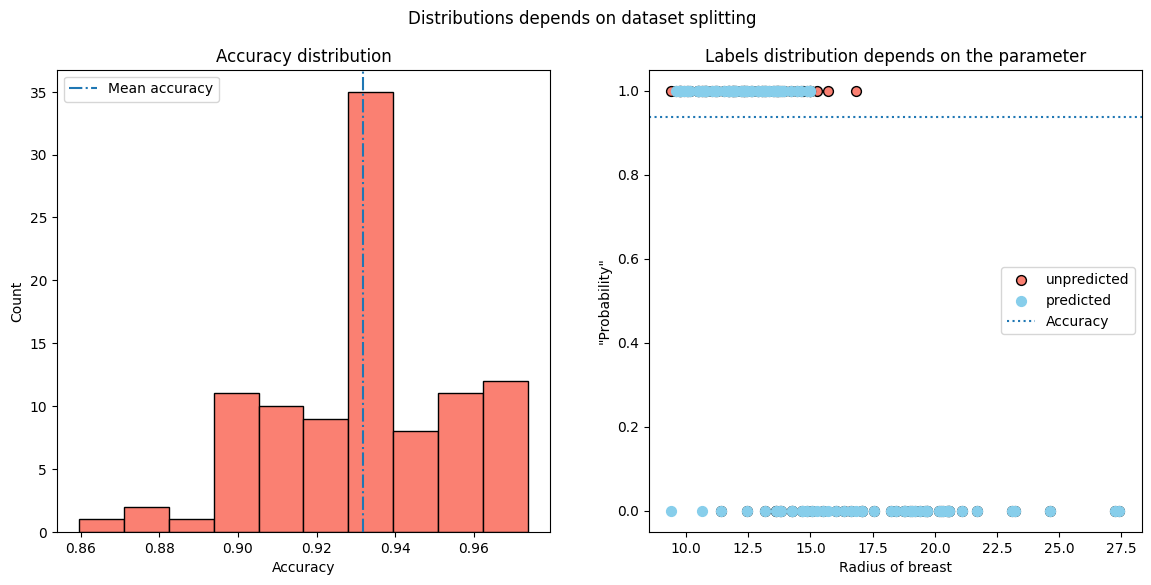

In [110]:
from sklearn import datasets
from sklearn.model_selection import train_test_split
import numpy as np


bc = datasets.load_breast_cancer()
X, y = bc.data, bc.target

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,6))

accs = []
for rs in range(1, 1000, 10):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=rs
    )
    
    clf = DecisionTree()
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    
    acc = np.sum(y_pred == y_test) / len(y_test)
    accs.append(acc)

mean = sum(accs) / len(accs)
ax1.hist(accs, bins=10, color='salmon', edgecolor='k')
ax1.axvline(mean, linestyle='-.', label='Mean accuracy')

ax1.set_title('Accuracy distribution')
ax1.set_ylabel('Count')
ax1.set_xlabel('Accuracy')
ax1.legend()

ax2.set_title('Labels distribution depends on the parameter')
ax2.scatter(X_test[:, 0], y_test, color='salmon', edgecolor='k', s=50, label='unpredicted')
ax2.scatter(X_test[:, 0], y_pred, color='skyblue', s=50, label='predicted')
ax2.axhline(acc, linestyle=':', label='Accuracy')
ax2.legend()
ax2.set_ylabel('"Probability"')
ax2.set_xlabel('Radius of breast')

fig.suptitle('Distributions depends on dataset splitting')
plt.legend()
plt.show()

In [2]:
from savkit import DecisionTree
from sklearn import datasets
from sklearn.model_selection import train_test_split

bc = datasets.load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(
    bc.data, bc.target, test_size=0.2, random_state=1234
)

clf = DecisionTree()
clf.fit(X_train, y_train)

NameError: name 'y' is not defined